In [37]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from layers.Invertible import RevIN
import torch.optim as optim
from torch.optim.lr_scheduler import ExponentialLR
from copy import deepcopy
import sys
sys.path.append('utils')
from data_generator import generate_m_seqs, generate_m_seqs_nn
import matplotlib.pyplot as plt

In [38]:
# for i in range(1):
#     _, tot_x, w_star, tot_y  = generate_m_seqs(200, 200, 3, 1+i, SGD=0)

In [39]:
gen_data = np.load("dataset/Neural_Network_1d_Adam/Sample_1/sample.npy")

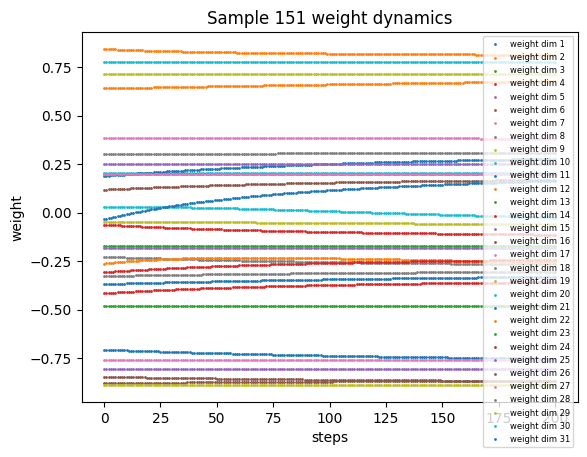

In [40]:
#
num_samps = 1
d = 31
tot_len = 201

for j in range(150,151):
    for i in range(d):
        plt.scatter(np.arange(tot_len), np.array(gen_data[j])[:,i],s=1, label ='weight dim {}'.format(i+1))
    plt.xlabel("steps")
    plt.ylabel("weight")
    plt.title("Sample {} weight dynamics".format(j+1))
    plt.legend(fontsize = 6)
    plt.show()

In [41]:
# # 
# num_samps = 1
# for j in range(num_samps):

#     fig, ax1 = plt.subplots()

#     for i in range(d):
#         ax1.scatter(np.arange(tot_len), np.array(gen_data[j])[:,i]- w_star[j,i],s=1, label ='weight residual dim {}'.format(i+1))
#         plt.xlabel("steps 1-{}".format(tot_len))
#         plt.ylabel("Actual residual: generated weight - optimal weight")

#     left, bottom, width, height = [0.45, 0.2, 0.2, 0.2]
#     ax2 = fig.add_axes([left, bottom, width, height])
#     for i in range(d):
#         ax2.scatter(np.arange(tot_len-20,tot_len), np.array(gen_data[j])[tot_len-20:,i]- w_star[j,i],s=1)
#     plt.show()

In [42]:
data_tr = gen_data[:100]
data_val = gen_data[100:150]
data_te = gen_data[150:]

In [43]:
tr_diff = np.sum(np.abs(data_tr[:,0,:] - data_tr[:,1,:]),axis=1)
# val_diff = np.sum(np.abs(data_val[:,0,:] - data_val[:,1,:]),axis=1)
# te_diff =np.sum( np.abs(data_te[:,0,:] - data_te[:,1,:]),axis=1)

In [44]:
k = 2 # --> correponding to len(t) which is last two

def get_batch_n(data,batch_size, k):
#     if data.shape[2] > 20:
#         outputb = np.zeros((batch_size,4, 20))
#         outputl = np.zeros((batch_size,1, 20))
#     else: 
    outputb = np.zeros((batch_size, k, data.shape[2]))
    outputl = np.zeros((batch_size,180, data.shape[2]))
    indices = np.arange(len(data))
    for i in range(batch_size):
        index = indices[i]
        b,l = get_batch(data[index,:,:])
        outputb[i,:,:] = b
        outputl[i,:,:] = l
        
    return outputb, outputl


def get_batch(train_data):
    

    data_width = train_data.shape[1]

    t = [0,20] # hard coded 
    batch = train_data[t,:]
    batch_indices = np.arange(data_width)
    labels = train_data[21:, :]

    return batch, labels
    


In [45]:
tr_W1, tr_W2 = get_batch_n(data_tr,len(data_tr),k)
tr_W1, tr_W2  = np.transpose(tr_W1, (0,2,1)),np.transpose(tr_W2, (0,2,1))
val_W1, val_W2 = get_batch_n(data_val,len(data_val),k)
val_W1, val_W2  = np.transpose(val_W1, (0,2,1)),np.transpose(val_W2, (0,2,1))
te_W1, te_W2 = get_batch_n(data_te,len(data_te),k)
te_W1, te_W2  = np.transpose(te_W1, (0,2,1)),np.transpose(te_W2, (0,2,1))


In [46]:
np.random.seed(0)
torch.manual_seed(0)


# Convert numpy arrays to PyTorch tensors
X_tensor = torch.from_numpy(tr_W1).float()
y_tensor = torch.from_numpy(tr_W2).float()

X_tensor_val = torch.from_numpy(val_W1).float()
y_tensor_val = torch.from_numpy(val_W2).float()

X_tensor_te = torch.from_numpy(te_W1).float()
y_tensor_te = torch.from_numpy(te_W2).float()


# Convert numpy arrays to PyTorch tensors
grad_diff_tensor_tr = torch.from_numpy(tr_diff).float()

#grad_diff_tensor_val = torch.from_numpy(val_diff).float()

#diff_tensor_te = torch.from_numpy(te_W1).float()


# Define the linear regression model
class LinearRegressionModel(nn.Module):
    def __init__(self, input_size,output_size):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        return self.linear(x)

input_size = tr_W1.shape[2]

output_size = tr_W2.shape[2]

learn_rate = 0.004

model = LinearRegressionModel(input_size,output_size)

# Loss and optimizer
optimizer = optim.Adam(model.parameters(), lr=learn_rate)

# Training the model
num_epochs = 10000

#batchsize
batch_size = 32

best_val_loss = float('inf')
best_model = deepcopy(model.state_dict())
val_loss_list = [] 
impatient = 0 

beta = 0.000001

for epoch in range(num_epochs):
    # Forward pass
    indices = torch.randperm(len(X_tensor))

    for i in range(0, len(X_tensor), batch_size):
        batch_indices = indices[i:i+batch_size]

        outputs = model( X_tensor[batch_indices])
        
        predict_grad_diff = torch.sum(torch.abs(outputs[:,:,-1] - outputs[:,:,-2]),axis =1)
        
        
        penalty = torch.mean(torch.relu( predict_grad_diff - grad_diff_tensor_tr[batch_indices] ))  
        
       # print(penalty)

        # Compute the loss : 
        loss = torch.squeeze(torch.mean(torch.abs(outputs - y_tensor[batch_indices])))  + beta*penalty


        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    #tr_loss = torch.squeeze(torch.mean(torch.abs(model(X_tensor) - y_tensor)))
    
    val_loss= torch.squeeze(torch.mean(torch.abs(model(X_tensor_val) - y_tensor_val)))
    #print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {tr_loss.item():.10f}, val Loss: {val_loss.item():.10f} ')

    if  val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = deepcopy(model.state_dict())
            impatient = 0 # reset
    else:
        impatient += 1


    if impatient >= 5:
        print(f'Breaking due to early stopping at epoch {epoch}')
        break


Breaking due to early stopping at epoch 883


In [47]:
# evaluate
model.load_state_dict(best_model)
    
model.eval()

pred = model(X_tensor_te)


for k in [2,3,4,5,6,7,8,9,10]:
    mse = torch.mean(torch.squeeze(torch.square(pred[:,:,20*(k-1)-1] - y_tensor_te[:,:,20*(k-1)-1])))

    print("mse of test samples {} at predicting time step {} ".format(mse, k*20 ) )

# predicted 
te_W2_pred = np.transpose(pred.detach().numpy(), (0,2,1))


mse of test samples 7.838156307116151e-05 at predicting time step 40 
mse of test samples 0.0010549454018473625 at predicting time step 60 
mse of test samples 0.0011265394277870655 at predicting time step 80 
mse of test samples 0.0030925972387194633 at predicting time step 100 
mse of test samples 0.003947014454752207 at predicting time step 120 
mse of test samples 0.004267663694918156 at predicting time step 140 
mse of test samples 0.003935640212148428 at predicting time step 160 
mse of test samples 0.006142925005406141 at predicting time step 180 
mse of test samples 0.006092830561101437 at predicting time step 200 


In [48]:
# true trajactory vs predict trajoctory
true = np.concatenate((data_te[:,:21,:],np.transpose(te_W2, (0,2,1))), axis = 1)
predicted = np.concatenate((data_te[:,:21,:],te_W2_pred), axis = 1)

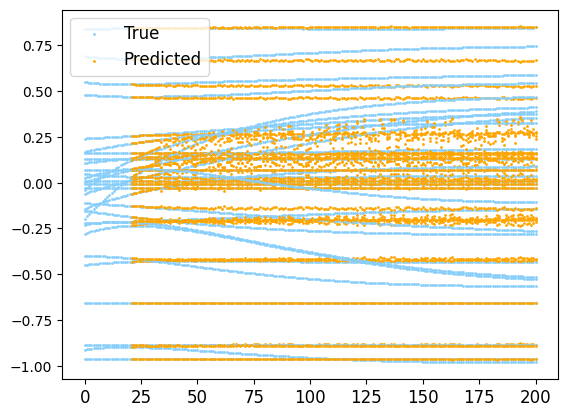

In [49]:
for j in range(9,10):
    for i in range(31):
        if i == 0:
            truelabel = 'True'
            predlabel = 'Predicted'
        else:
            truelabel = None
            predlabel = None
        plt.scatter(np.arange(0, len(true[j])), true[j,:,i], s= 1,label =truelabel, c= 'lightskyblue')
        plt.scatter(np.arange(21, tot_len), te_W2_pred[j,:,i], s= 1,label =predlabel, c='orange')
   # plt.xlabel("Time Steps")
    # plt.ylabel("weight")
 #   plt.title("Sample {} weight dynamics".format(j+1))
plt.legend(fontsize = 12, loc = 'upper left')
plt.xticks(fontsize=12)
plt.show() 